english: 101 files loaded
hindi: 101 files loaded
malayalam: 101 files loaded
marathi: 101 files loaded
telugu: 101 files loaded

Total samples loaded: 505
Languages: {'telugu', 'malayalam', 'english', 'marathi', 'hindi'}
Encoded Classes: ['english' 'hindi' 'malayalam' 'marathi' 'telugu']

Training Started...

Epoch 1/10, Loss: 50.3317
Epoch 2/10, Loss: 26.9460
Epoch 3/10, Loss: 18.1324
Epoch 4/10, Loss: 13.6024
Epoch 5/10, Loss: 12.0152
Epoch 6/10, Loss: 10.3516
Epoch 7/10, Loss: 8.3554
Epoch 8/10, Loss: 7.4294
Epoch 9/10, Loss: 6.5285
Epoch 10/10, Loss: 6.0500

Training Completed!

Accuracy: 0.8415841584158416

              precision    recall  f1-score   support

     english       0.77      0.77      0.77        26
       hindi       0.92      1.00      0.96        12
   malayalam       0.83      0.88      0.86        17
     marathi       0.87      1.00      0.93        20
      telugu       0.86      0.69      0.77        26

    accuracy                           0.84       101

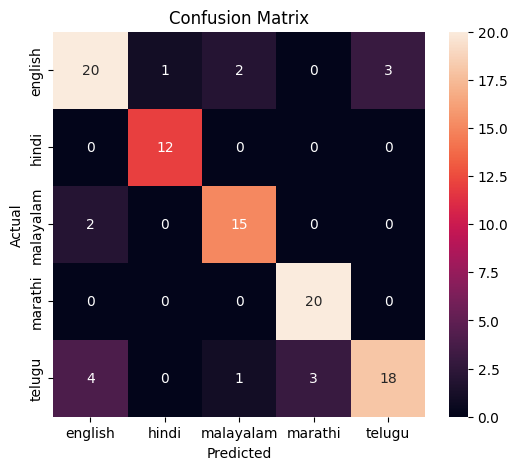


Model saved at ../outputs/model.pth


In [2]:
import os
import numpy as np
import librosa
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

DATA_PATH = "../data"

def extract_features(file_path):
    try:
        # Load audio
        audio, sr = librosa.load(file_path, sr=16000)

        # Remove silence
        audio, _ = librosa.effects.trim(audio)

        # Skip very small/broken audio
        if len(audio) < 1000:
            return None

        # MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc = np.mean(mfcc.T, axis=0)

        # MEL Spectrogram
        mel = librosa.feature.melspectrogram(y=audio, sr=sr)
        mel = np.mean(mel.T, axis=0)

        # Combine features
        features = np.concatenate([mfcc, mel])

        return features

    except:
        return None

X, y = [], []

for label in os.listdir(DATA_PATH):
    folder = os.path.join(DATA_PATH, label)

    if not os.path.isdir(folder):
        continue

    count = 0

    for file in os.listdir(folder):
        if file.endswith(".mp3"):   # KEEP MP3 (working)
            path = os.path.join(folder, file)

            features = extract_features(path)

            if features is not None:
                X.append(features)
                y.append(label)
                count += 1

    print(f"{label}: {count} files loaded")

X = np.array(X)
y = np.array(y)

print("\nTotal samples loaded:", len(X))
print("Languages:", set(y))

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Encoded Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=16,
    shuffle=True
)

class Model(torch.nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_size, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = Model(X.shape[1], len(set(y_encoded)))

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("\nTraining Started...\n")

for epoch in range(10):
    total_loss = 0

    for xb, yb in train_loader:
        preds = model(xb)
        loss = loss_fn(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/10, Loss: {total_loss:.4f}")

print("\nTraining Completed!")

model.eval()

with torch.no_grad():
    preds = model(X_test).argmax(dim=1).numpy()

acc = accuracy_score(y_test, preds)

print("\n==============================")
print("Accuracy:", acc)
print("==============================\n")

print(classification_report(y_test, preds, target_names=le.classes_))

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

os.makedirs("../outputs", exist_ok=True)
torch.save(model.state_dict(), "../outputs/model.pth")

print("\nModel saved at ../outputs/model.pth")